# Q4 — Classificação do risco de não atingir a meta

Este notebook responde à pergunta:

> **Q4. Como prever municípios que podem não atingir metas futuras?**

A abordagem é de **classificação binária supervisionada**:

- `risco_nao_atingir_meta = 1` quando `taxa_realizada < meta`;
- `risco_nao_atingir_meta = 0` quando `taxa_realizada >= meta`.

A unidade de análise permanece **(município, ano)**.

A diferença conceitual em relação à Q2 é importante:

- **Q2** identifica vulnerabilidade educacional absoluta;
- **Q4** estima o risco de o município ficar abaixo de uma **meta específica já conhecida antes do resultado**.

Por isso, `meta` pode ser utilizada como feature em Q4. Também será avaliada a variável `esforco_pactuado`, definida como a diferença entre a meta atual e a taxa observada no período anterior:

```python
esforco_pactuado = meta - taxa_lag1
```

A estratégia temporal será:

- **2024 = desenvolvimento**;
- **2025 = teste temporal final**.

Neste primeiro trecho, **nenhum modelo será treinado**. Antes da modelagem, precisamos confirmar:

1. se o target está consistente com a regra pactuada;
2. quais features podem ser utilizadas sem vazamento de informação;
3. se `meta` e `esforco_pactuado` estão consistentes;
4. como o target se distribui em 2024 e 2025;
5. quão estável é a condição de cumprimento da meta entre os dois anos.

As próximas decisões de modelagem serão tomadas somente depois de observar esses resultados.

## 1. Ambiente e leitura da base

A entrada é a base município-ano já preparada anteriormente:

`/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet`

O ano de **2024** será usado para desenvolvimento dos modelos.

O ano de **2025** será preservado como teste temporal final. Nesta etapa inicial, 2025 será observado apenas de forma **descritiva**, para entender a prevalência e a estabilidade do target. Ele não será usado para treinar, selecionar ou ajustar modelos.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

ARQUIVO_DADOS_MODELAGEM = Path(
    '/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet'
)

if not ARQUIVO_DADOS_MODELAGEM.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {ARQUIVO_DADOS_MODELAGEM}\n'
        'Confirme se o Google Drive foi montado e se a base está no caminho esperado.'
    )

dados = pd.read_parquet(ARQUIVO_DADOS_MODELAGEM)

print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]:,} colunas')
display(dados.head())

Dimensões: 11,073 linhas × 50 colunas


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


## 2. Auditoria mínima da unidade de análise

Antes de analisar o target, validamos apenas o necessário para este notebook:

- presença de 2024 e 2025;
- presença das chaves `ano`, `id_uf` e `id_municipio`;
- ausência de duplicidade em `(id_municipio, ano)`;
- quantidade de municípios por ano.

Essa checagem evita interpretar registros duplicados como unidades diferentes.

In [3]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio']
ANOS_ANALISE = [2024, 2025]

faltantes_chave = [c for c in COLUNAS_CHAVE if c not in dados.columns]
if faltantes_chave:
    raise KeyError(f'Colunas-chave ausentes: {faltantes_chave}')

anos_encontrados = sorted(dados['ano'].dropna().unique().tolist())
print('Anos encontrados:', anos_encontrados)

for ano in ANOS_ANALISE:
    if ano not in anos_encontrados:
        raise ValueError(f'O ano {ano} não está presente na base.')

duplicados = dados.duplicated(subset=['id_municipio', 'ano'], keep=False)

print(f'Duplicidades em (id_municipio, ano): {duplicados.sum():,}')

if duplicados.any():
    display(
        dados.loc[duplicados, COLUNAS_CHAVE]
        .sort_values(['id_municipio', 'ano'])
        .head(20)
    )
    raise ValueError(
        'Foram encontradas duplicidades na unidade município-ano. '
        'Corrija a base antes de continuar.'
    )

municipios_por_ano = (
    dados.groupby('ano')
    .size()
    .rename('municipios')
    .to_frame()
)

display(municipios_por_ano.loc[ANOS_ANALISE])

Anos encontrados: [2024, 2025]
Duplicidades em (id_municipio, ano): 0


,municipios
ano,
2024,5517
2025,5556


## 3. Validação da definição do target de Q4

O target já existe na base como `risco_nao_atingir_meta`.

A regra pactuada é:

```python
risco_nao_atingir_meta = 1  # taxa_realizada < meta
risco_nao_atingir_meta = 0  # taxa_realizada >= meta
```

Neste notebook **não redefinimos o target**. Apenas verificamos se o valor salvo na base respeita essa regra.

`taxa_realizada` será utilizada nesta seção **somente para auditoria**. Ela não poderá entrar no conjunto de features porque determina diretamente o target que queremos prever.

In [4]:
TARGET_Q4 = 'risco_nao_atingir_meta'
COLUNA_TAXA = 'taxa_realizada'
COLUNA_META = 'meta'

colunas_obrigatorias = [TARGET_Q4, COLUNA_TAXA, COLUNA_META]
faltantes = [c for c in colunas_obrigatorias if c not in dados.columns]

if faltantes:
    raise KeyError(f'Colunas obrigatórias ausentes para Q4: {faltantes}')

# Primeiro verificamos todos os valores não nulos encontrados no target.
target_nao_nulo = pd.to_numeric(
    dados.loc[dados[TARGET_Q4].notna(), TARGET_Q4],
    errors='raise'
)

valores_target = sorted(target_nao_nulo.unique().tolist())
print('Valores observados no target:', valores_target)

if not set(valores_target).issubset({0, 1}):
    raise ValueError(
        f'O target deveria ser binário (0/1), mas foram encontrados: {valores_target}'
    )

# A regra só pode ser auditada onde target, taxa realizada e meta estão disponíveis.
base_validacao_target = dados.loc[
    dados[TARGET_Q4].notna()
    & dados[COLUNA_TAXA].notna()
    & dados[COLUNA_META].notna(),
    ['ano', 'id_uf', 'id_municipio', COLUNA_TAXA, COLUNA_META, TARGET_Q4]
].copy()

target_esperado = (
    base_validacao_target[COLUNA_TAXA]
    < base_validacao_target[COLUNA_META]
).astype(int)

target_observado = pd.to_numeric(
    base_validacao_target[TARGET_Q4],
    errors='raise'
).astype(int)

divergencia = target_observado.ne(target_esperado)
n_divergencias = int(divergencia.sum())

print(f'Observações auditadas: {len(base_validacao_target):,}')
print(f'Divergências com a regra taxa_realizada < meta: {n_divergencias:,}')

if n_divergencias > 0:
    display(
        base_validacao_target.loc[divergencia]
        .assign(risco_esperado=target_esperado.loc[divergencia])
        .head(20)
    )
    raise ValueError(
        'O target risco_nao_atingir_meta não está consistente com a regra pactuada. '
        'A modelagem deve parar até essa inconsistência ser corrigida.'
    )

print('Target validado: risco_nao_atingir_meta está consistente com taxa_realizada < meta.')

Valores observados no target: [0.0, 1.0]
Observações auditadas: 10,941
Divergências com a regra taxa_realizada < meta: 0
Target validado: risco_nao_atingir_meta está consistente com taxa_realizada < meta.


## 4. Controle preliminar das features

Antes do treinamento, as colunas são separadas pelo **motivo da exclusão**.

### Identificadores

São mantidos apenas para rastreabilidade e para identificar municípios nas análises finais. Não entram no modelo.

### Vazamento de informação

São variáveis que representam o resultado corrente ou são derivadas diretamente dele. Se entrassem em `X`, o modelo teria acesso a informações que não estariam disponíveis no momento real da previsão.

### Exclusões por política do projeto

Algumas variáveis não são necessariamente vazamento, mas já foram excluídas do conjunto estrutural adotado no projeto.

Em Q4, há uma diferença importante em relação à Q2:

- `meta` **permanece candidata**, porque é conhecida antes do resultado;
- `esforco_pactuado` **permanece candidata**, pois combina `meta` com `taxa_lag1`, uma informação histórica;
- `risco_educacional` é proibida, porque deriva da `taxa_realizada` corrente.

A lista criada nesta etapa ainda é **preliminar**. A lista final de features será definida apenas depois das auditorias deste primeiro checkpoint.

In [5]:
IDENTIFICADORES_Q4 = [
    'ano',
    'id_uf',
    'id_municipio',
    'nome_municipio',
]

VAZAMENTO_Q4 = [
    'risco_nao_atingir_meta',
    'risco_educacional',
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
]

# Não são necessariamente leakage. Permanecem fora para manter a política
# estrutural já adotada nas etapas anteriores do projeto.
EXCLUIDAS_POLITICA_Q4 = [
    'alunos',
    'escolas',
    'pct_rede_municipal',
]

identificadores_presentes = [
    c for c in IDENTIFICADORES_Q4 if c in dados.columns
]

vazamento_presente = [
    c for c in VAZAMENTO_Q4 if c in dados.columns
]

excluidas_politica_presentes = [
    c for c in EXCLUIDAS_POLITICA_Q4 if c in dados.columns
]

FEATURES_CANDIDATAS_Q4 = sorted([
    c for c in dados.columns
    if c not in set(
        identificadores_presentes
        + vazamento_presente
        + excluidas_politica_presentes
    )
])

print(f'Features candidatas para Q4: {len(FEATURES_CANDIDATAS_Q4)}')

print('\nIdentificadores excluídos:')
print(identificadores_presentes)

print('\nVariáveis excluídas por vazamento:')
print(vazamento_presente)

print('\nVariáveis excluídas pela política do projeto:')
print(excluidas_politica_presentes)

print('\nFeatures candidatas restantes:')
display(pd.DataFrame({'feature': FEATURES_CANDIDATAS_Q4}))

# Nenhuma coluna proibida pode permanecer entre as candidatas.
assert not set(identificadores_presentes).intersection(FEATURES_CANDIDATAS_Q4)
assert not set(vazamento_presente).intersection(FEATURES_CANDIDATAS_Q4)
assert not set(excluidas_politica_presentes).intersection(FEATURES_CANDIDATAS_Q4)
assert TARGET_Q4 not in FEATURES_CANDIDATAS_Q4
assert 'taxa_realizada' not in FEATURES_CANDIDATAS_Q4

# Features particularmente importantes para Q4.
features_q4_de_interesse = [
    'meta',
    'esforco_pactuado',
    'taxa_lag1',
    'proficiencia_lag1',
    'participacao_lag1',
]

print('\nFeatures de interesse específicas/históricas encontradas:')
for feature in features_q4_de_interesse:
    status = 'presente' if feature in FEATURES_CANDIDATAS_Q4 else 'ausente'
    print(f'- {feature}: {status}')

assert 'meta' in FEATURES_CANDIDATAS_Q4, (
    'A coluna meta deveria permanecer disponível como feature candidata de Q4.'
)

Features candidatas para Q4: 38

Identificadores excluídos:
['ano', 'id_uf', 'id_municipio', 'nome_municipio']

Variáveis excluídas por vazamento:
['risco_nao_atingir_meta', 'risco_educacional', 'taxa_realizada', 'proficiencia_media', 'distancia_ate_a_meta']

Variáveis excluídas pela política do projeto:
['alunos', 'escolas', 'pct_rede_municipal']

Features candidatas restantes:


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5



Features de interesse específicas/históricas encontradas:
- meta: presente
- esforco_pactuado: presente
- taxa_lag1: presente
- proficiencia_lag1: presente
- participacao_lag1: presente


## 5. Auditoria de `meta` e `esforco_pactuado`

Q4 depende diretamente do referencial pactuado para cada município. Por isso, antes da modelagem, verificamos a qualidade das variáveis mais específicas desta pergunta.

Serão observados:

- valores ausentes de `meta` por ano;
- valores ausentes de `taxa_lag1` por ano;
- valores ausentes de `esforco_pactuado` por ano;
- estatísticas simples de `meta` e `esforco_pactuado`;
- consistência da relação `esforco_pactuado = meta - taxa_lag1`.

A intenção aqui não é fazer uma nova EDA. É apenas confirmar que essas variáveis podem seguir para a etapa de modelagem.

In [6]:
colunas_auditoria = [
    c for c in ['meta', 'taxa_lag1', 'esforco_pactuado']
    if c in dados.columns
]

print('Colunas disponíveis para auditoria:', colunas_auditoria)

linhas_missing = []

for ano in ANOS_ANALISE:
    dados_ano = dados.loc[dados['ano'].eq(ano)]
    total_ano = len(dados_ano)

    for coluna in colunas_auditoria:
        n_nulos = int(dados_ano[coluna].isna().sum())
        linhas_missing.append({
            'ano': ano,
            'variavel': coluna,
            'nulos': n_nulos,
            'percentual_nulos': n_nulos / total_ano * 100 if total_ano else np.nan,
        })

tabela_missing_q4 = pd.DataFrame(linhas_missing)

print('\nValores ausentes:')
display(tabela_missing_q4)

print('\nEstatísticas de meta por ano:')
display(
    dados.loc[dados['ano'].isin(ANOS_ANALISE)]
    .groupby('ano')['meta']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

if 'esforco_pactuado' in dados.columns:
    print('\nEstatísticas de esforco_pactuado por ano:')
    display(
        dados.loc[dados['ano'].isin(ANOS_ANALISE)]
        .groupby('ano')['esforco_pactuado']
        .agg(['count', 'mean', 'median', 'min', 'max'])
    )
else:
    print(
        '\nATENÇÃO: esforco_pactuado não está presente na base. '
        'A decisão sobre criá-la será tomada após este checkpoint.'
    )

Colunas disponíveis para auditoria: ['meta', 'taxa_lag1', 'esforco_pactuado']

Valores ausentes:


,ano,variavel,nulos,percentual_nulos
0,2024,meta,75,1.359
1,2024,taxa_lag1,100,1.813
2,2024,esforco_pactuado,121,2.193
3,2025,meta,57,1.026
4,2025,taxa_lag1,115,2.070
5,2025,esforco_pactuado,126,2.268



Estatísticas de meta por ano:


,count,mean,median,min,max
ano,,,,,
2024,5442,61.652,64.000,0.000,80.000
2025,5499,64.642,67.000,0.000,80.000



Estatísticas de esforco_pactuado por ano:


,count,mean,median,min,max
ano,,,,,
2024,5396,1.531,3.150,-91.720,61.190
2025,5430,2.147,2.310,-83.740,68.900


In [7]:
if {'meta', 'taxa_lag1', 'esforco_pactuado'}.issubset(dados.columns):
    mascara_validacao_esforco = (
        dados['meta'].notna()
        & dados['taxa_lag1'].notna()
        & dados['esforco_pactuado'].notna()
    )

    base_validacao_esforco = dados.loc[
        mascara_validacao_esforco,
        [
            'ano',
            'id_municipio',
            'meta',
            'taxa_lag1',
            'esforco_pactuado',
        ]
    ].copy()

    esforco_esperado = (
        base_validacao_esforco['meta']
        - base_validacao_esforco['taxa_lag1']
    )

    divergencia_esforco = ~np.isclose(
        base_validacao_esforco['esforco_pactuado'],
        esforco_esperado,
        rtol=1e-7,
        atol=1e-6,
        equal_nan=False,
    )

    n_divergencias_esforco = int(divergencia_esforco.sum())

    print(f'Registros auditados em esforco_pactuado: {len(base_validacao_esforco):,}')
    print(f'Divergências encontradas: {n_divergencias_esforco:,}')

    if n_divergencias_esforco > 0:
        display(
            base_validacao_esforco.loc[divergencia_esforco]
            .assign(
                esforco_esperado=esforco_esperado.loc[divergencia_esforco],
                diferenca=(
                    base_validacao_esforco.loc[
                        divergencia_esforco,
                        'esforco_pactuado'
                    ]
                    - esforco_esperado.loc[divergencia_esforco]
                )
            )
            .head(20)
        )
        raise ValueError(
            'esforco_pactuado não está consistente com meta - taxa_lag1. '
            'A modelagem deve parar até essa inconsistência ser investigada.'
        )

    print('esforco_pactuado validado: consistente com meta - taxa_lag1.')
else:
    faltantes_esforco = sorted(
        {'meta', 'taxa_lag1', 'esforco_pactuado'} - set(dados.columns)
    )
    print(
        'Validação de esforco_pactuado não executada. '
        f'Colunas ausentes: {faltantes_esforco}'
    )

Registros auditados em esforco_pactuado: 10,826
Divergências encontradas: 0
esforco_pactuado validado: consistente com meta - taxa_lag1.


## 6. Distribuição do target de Q4

Agora observamos a prevalência de `risco_nao_atingir_meta` em cada ano.

Esta análise responde perguntas simples, mas importantes:

1. qual percentual de municípios não atingiu a meta em 2024;
2. qual percentual não atingiu a meta em 2025;
3. se a classe positiva (`risco = 1`) é minoritária ou majoritária;
4. se houve mudança relevante de prevalência entre os dois anos.

A distribuição será usada para registrar a estratégia de avaliação na seção seguinte. A decisão de usar
`class_weight='balanced'` será documentada após observar os resultados, sem utilizar 2025 para escolher
modelo ou hiperparâmetros.


In [8]:
base_target_q4 = dados.loc[
    dados['ano'].isin(ANOS_ANALISE) & dados[TARGET_Q4].notna(),
    ['ano', 'id_municipio', TARGET_Q4]
].copy()

base_target_q4[TARGET_Q4] = pd.to_numeric(
    base_target_q4[TARGET_Q4],
    errors='raise'
).astype(int)

distribuicao_q4 = (
    base_target_q4
    .groupby(['ano', TARGET_Q4])
    .size()
    .rename('municipios')
    .reset_index()
)

totais_ano_q4 = (
    base_target_q4.groupby('ano')
    .size()
    .rename('total_municipios')
)

distribuicao_q4['percentual'] = (
    distribuicao_q4['municipios']
    / distribuicao_q4['ano'].map(totais_ano_q4)
    * 100
)

distribuicao_q4['classe'] = distribuicao_q4[TARGET_Q4].map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

tabela_distribuicao_q4 = (
    distribuicao_q4[
        ['ano', 'classe', 'municipios', 'percentual']
    ]
    .sort_values(['ano', 'classe'])
    .reset_index(drop=True)
)

display(tabela_distribuicao_q4)

,ano,classe,municipios,percentual
0,2024,Atingiu/superou a meta,2964,54.465
1,2024,Não atingiu a meta,2478,45.535
2,2025,Atingiu/superou a meta,3999,72.722
3,2025,Não atingiu a meta,1500,27.278


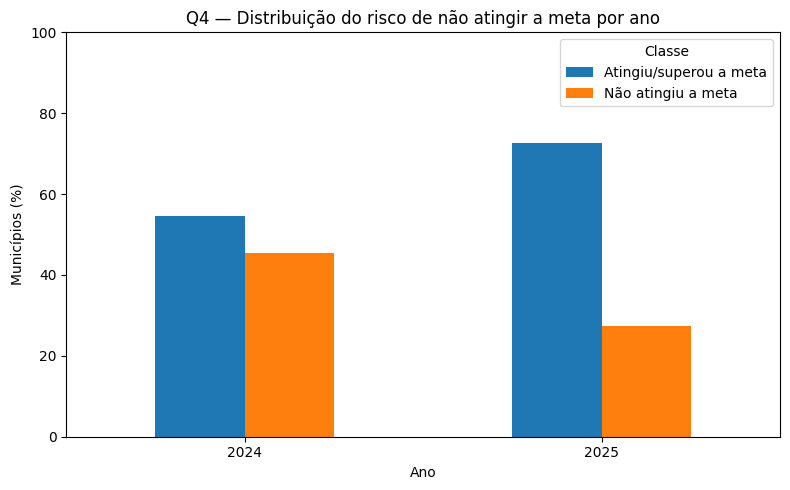

In [9]:
grafico_q4 = (
    distribuicao_q4
    .pivot(index='ano', columns='classe', values='percentual')
    .fillna(0)
)

ax = grafico_q4.plot(
    kind='bar',
    figsize=(8, 5)
)

ax.set_title('Q4 — Distribuição do risco de não atingir a meta por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Municípios (%)')
ax.set_ylim(0, max(100, grafico_q4.to_numpy().max() * 1.15))
ax.legend(title='Classe')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Estabilidade temporal do target

Além da distribuição em cada ano, precisamos entender quantos municípios mudaram de condição entre 2024 e 2025.

Consideramos somente os municípios:

- presentes nos dois anos;
- com `risco_nao_atingir_meta` válido em 2024 e 2025.

As quatro transições possíveis são:

- atingiu → atingiu;
- atingiu → não atingiu;
- não atingiu → atingiu;
- não atingiu → não atingiu.

Essa tabela é **descritiva**. Ela não mede desempenho de modelo e não deve ser usada para ajustar o teste temporal de 2025.

In [10]:
risco_meta_por_ano = (
    base_target_q4
    .pivot(index='id_municipio', columns='ano', values=TARGET_Q4)
    .dropna(subset=[2024, 2025])
    .rename(columns={
        2024: 'risco_2024',
        2025: 'risco_2025',
    })
    .astype(int)
)

rotulo_meta = {
    0: 'Atingiu',
    1: 'Não atingiu',
}

risco_meta_por_ano['transicao'] = (
    risco_meta_por_ano['risco_2024'].map(rotulo_meta)
    + ' → '
    + risco_meta_por_ano['risco_2025'].map(rotulo_meta)
)

transicoes_q4 = (
    risco_meta_por_ano['transicao']
    .value_counts()
    .rename('municipios')
    .to_frame()
)

transicoes_q4['percentual'] = (
    transicoes_q4['municipios']
    / len(risco_meta_por_ano)
    * 100
)

print(f'Municípios comparáveis em 2024 e 2025: {len(risco_meta_por_ano):,}')
display(transicoes_q4)

n_passou_nao_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 0)
     & (risco_meta_por_ano['risco_2025'] == 1)).sum()
)

n_passou_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 1)
     & (risco_meta_por_ano['risco_2025'] == 0)).sum()
)

n_permaneceu_nao_atingir = int(
    ((risco_meta_por_ano['risco_2024'] == 1)
     & (risco_meta_por_ano['risco_2025'] == 1)).sum()
)

n_permaneceu_atingiu = int(
    ((risco_meta_por_ano['risco_2024'] == 0)
     & (risco_meta_por_ano['risco_2025'] == 0)).sum()
)

print(f'Atingiu → não atingiu:      {n_passou_nao_atingir:,}')
print(f'Não atingiu → atingiu:      {n_passou_atingir:,}')
print(f'Não atingiu → não atingiu:  {n_permaneceu_nao_atingir:,}')
print(f'Atingiu → atingiu:          {n_permaneceu_atingiu:,}')

Municípios comparáveis em 2024 e 2025: 5,430


,municipios,percentual
transicao,,
Atingiu → Atingiu,2572,47.366
Não atingiu → Atingiu,1380,25.414
Não atingiu → Não atingiu,1090,20.074
Atingiu → Não atingiu,388,7.145


Atingiu → não atingiu:      388
Não atingiu → atingiu:      1,380
Não atingiu → não atingiu:  1,090
Atingiu → atingiu:          2,572


## 8. Conclusões do Checkpoint 1 e decisões para a modelagem

Os resultados da auditoria permitem avançar com algumas decisões explícitas:

- a unidade município-ano está íntegra, sem duplicidades;
- `risco_nao_atingir_meta` foi validado e respeita a regra `taxa_realizada < meta`;
- em 2024, a classe de risco representa aproximadamente **45,5%** dos registros válidos;
- em 2025, essa participação cai para aproximadamente **27,3%**, indicando uma mudança temporal relevante;
- `meta`, `taxa_lag1` e `esforco_pactuado` possuem baixa proporção de nulos;
- `esforco_pactuado` foi validado como `meta - taxa_lag1`.

### Decisões adotadas a partir daqui

1. **Remover `meta == 0` da base específica de Q4.**  
   Esses registros não representam um referencial de meta útil para o problema de não cumprimento. A mesma regra será aplicada em 2024 e 2025. Valores nulos de `meta` não serão removidos por essa regra; quando aplicável, serão tratados dentro do `Pipeline`.

2. **Usar `class_weight='balanced'` nos classificadores.**  
   Embora 2024 esteja relativamente equilibrado, a classe positiva torna-se claramente minoritária em 2025 e representa o evento operacional de maior interesse. O balanceamento será usado como decisão de modelagem, mas seu desempenho ainda deverá ser avaliado por cross-validation.

3. **Evitar redundância perfeita entre `meta`, `taxa_lag1` e `esforco_pactuado`.**  
   Como `esforco_pactuado = meta - taxa_lag1`, manteremos `meta` e `esforco_pactuado` em `X` e retiraremos `taxa_lag1` do conjunto preditivo. `taxa_lag1` continuará disponível para interpretação e análise de negócio.

4. **Usar somente as variáveis já disponíveis no projeto.**  
   Não criaremos uma nova variável categórica de dependência administrativa. `pct_rede_municipal` continua fora do modelo conforme a política já adotada.

5. **Manter 2025 fora do desenvolvimento.**  
   A prevalência observada em 2025 serve apenas para caracterizar a mudança temporal. Modelo, features e threshold serão definidos usando somente 2024.

A próxima etapa será:

> **filtro de `meta == 0` → features finais → desenvolvimento 2024 → preprocessing numérico → baselines → Logistic Regression → Decision Tree → cross-validation**


## 9. Regra de elegibilidade de Q4: remover `meta == 0`

A modelagem de Q4 exige uma meta municipal válida como referência. Por decisão metodológica do projeto,
registros com `meta == 0` serão retirados **antes** de montar os conjuntos supervisionados.

Importante:

- a regra remove apenas `meta == 0`;
- `meta` ausente não é removida por esse filtro;
- registros sem target válido serão excluídos apenas quando `X` e `y` forem construídos;
- a mesma regra de elegibilidade será aplicada aos dois anos.

Primeiro quantificamos o impacto do filtro e revalidamos o target na base elegível.


In [11]:
# A regra abaixo preserva meta nula e remove somente meta exatamente igual a zero.
mascara_meta_zero = dados['meta'].eq(0)

removidos_meta_zero = (
    dados.loc[mascara_meta_zero]
    .groupby('ano')
    .size()
    .reindex(ANOS_ANALISE, fill_value=0)
    .rename('registros_removidos_meta_zero')
    .to_frame()
)

print('Registros removidos por meta == 0:')
display(removidos_meta_zero)

dados_q4 = dados.loc[~mascara_meta_zero].copy()

print(f'Registros antes do filtro: {len(dados):,}')
print(f'Registros após o filtro:  {len(dados_q4):,}')

# Revalidação do target apenas onde target, taxa e meta estão disponíveis.
base_revalidacao_target = dados_q4.loc[
    dados_q4[TARGET_Q4].notna()
    & dados_q4[COLUNA_TAXA].notna()
    & dados_q4[COLUNA_META].notna(),
    ['ano', 'id_municipio', COLUNA_TAXA, COLUNA_META, TARGET_Q4]
].copy()

target_esperado_filtrado = (
    base_revalidacao_target[COLUNA_TAXA]
    < base_revalidacao_target[COLUNA_META]
).astype(int)

target_observado_filtrado = pd.to_numeric(
    base_revalidacao_target[TARGET_Q4],
    errors='raise'
).astype(int)

n_divergencias_filtrado = int(
    target_observado_filtrado.ne(target_esperado_filtrado).sum()
)

print(f'Observações revalidadas após o filtro: {len(base_revalidacao_target):,}')
print(f'Divergências após o filtro: {n_divergencias_filtrado:,}')

assert n_divergencias_filtrado == 0

# Distribuição do target após a regra de elegibilidade.
distribuicao_filtrada_q4 = (
    dados_q4.loc[
        dados_q4['ano'].isin(ANOS_ANALISE)
        & dados_q4[TARGET_Q4].notna()
    ]
    .groupby(['ano', TARGET_Q4])
    .size()
    .rename('municipios')
    .reset_index()
)

totais_filtrados_q4 = (
    distribuicao_filtrada_q4
    .groupby('ano')['municipios']
    .transform('sum')
)

distribuicao_filtrada_q4['percentual'] = (
    distribuicao_filtrada_q4['municipios']
    / totais_filtrados_q4
    * 100
)

distribuicao_filtrada_q4['classe'] = distribuicao_filtrada_q4[TARGET_Q4].map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

print('\nDistribuição do target após remover meta == 0:')
display(
    distribuicao_filtrada_q4[
        ['ano', 'classe', 'municipios', 'percentual']
    ].sort_values(['ano', 'classe'])
)


Registros removidos por meta == 0:


,registros_removidos_meta_zero
ano,
2024,16
2025,46


Registros antes do filtro: 11,073
Registros após o filtro:  11,011
Observações revalidadas após o filtro: 10,879
Divergências após o filtro: 0

Distribuição do target após remover meta == 0:


,ano,classe,municipios,percentual
0,2024,Atingiu/superou a meta,2948,54.331
1,2024,Não atingiu a meta,2478,45.669
2,2025,Atingiu/superou a meta,3953,72.492
3,2025,Não atingiu a meta,1500,27.508


## 10. Revisão final das features de Q4

Partimos das features candidatas já auditadas.

Para manter o modelo simples e interpretável, retiramos `taxa_lag1` de `X`, pois:

```text
esforco_pactuado = meta - taxa_lag1
```

Logo, utilizar simultaneamente `meta`, `taxa_lag1` e `esforco_pactuado` introduziria uma relação algébrica
perfeita entre três variáveis.

Nesta primeira rodada não criaremos novas transformações além do preprocessing necessário aos modelos.
O objetivo é medir quanto os modelos básicos conseguem aprender usando as features já disponíveis.


In [12]:
FEATURES_Q4 = [
    c for c in FEATURES_CANDIDATAS_Q4
    if c != 'taxa_lag1'
]

print(f'Número de features finais de Q4: {len(FEATURES_Q4)}')
display(pd.DataFrame({'feature': FEATURES_Q4}))

# Verificações de segurança contra leakage e redundância deliberadamente removida.
assert TARGET_Q4 not in FEATURES_Q4
assert 'taxa_realizada' not in FEATURES_Q4
assert 'risco_educacional' not in FEATURES_Q4
assert 'distancia_ate_a_meta' not in FEATURES_Q4
assert 'id_municipio' not in FEATURES_Q4
assert 'id_uf' not in FEATURES_Q4
assert 'ano' not in FEATURES_Q4
assert 'taxa_lag1' not in FEATURES_Q4

# Features centrais de Q4 devem permanecer.
assert 'meta' in FEATURES_Q4
assert 'esforco_pactuado' in FEATURES_Q4

print('Features finais validadas.')


Número de features finais de Q4: 37


,feature
0,ctx_atlas_expectativa_anos_estudo
1,ctx_atlas_idhm_longevidade
2,ctx_atlas_indice_gini
3,ctx_atlas_percentual_domicilios_agua
4,ctx_atlas_percentual_domicilios_energia
5,ctx_atlas_taxa_analfabetismo_11a14
6,ctx_atlas_taxa_analfabetismo_15a17
7,ctx_atlas_taxa_analfabetismo_15mais
8,ctx_atlas_taxa_densidade_domiciliar
9,ctx_atlas_taxa_fora_escola_4a5


Features finais validadas.


## 11. Dados de desenvolvimento — somente 2024

Toda comparação de modelos será feita somente com 2024.

Nesta etapa:

- excluímos apenas registros sem target válido;
- mantemos nulos das features para serem tratados dentro do `Pipeline`;
- separamos os identificadores apenas para uso posterior;
- não criamos ainda o conjunto de teste de 2025.

Isso preserva 2025 como teste temporal final.


In [13]:
dados_q4_2024 = dados_q4.loc[
    dados_q4['ano'].eq(2024)
    & dados_q4[TARGET_Q4].notna()
].copy()

X_q4_2024 = dados_q4_2024[FEATURES_Q4].copy()

y_q4_2024 = pd.to_numeric(
    dados_q4_2024[TARGET_Q4],
    errors='raise'
).astype(int)

colunas_chave_disponiveis = [
    c for c in ['ano', 'id_uf', 'id_municipio', 'nome_municipio']
    if c in dados_q4_2024.columns
]

chaves_q4_2024 = dados_q4_2024[colunas_chave_disponiveis].copy()

assert X_q4_2024.index.equals(y_q4_2024.index)
assert not y_q4_2024.isna().any()
assert set(y_q4_2024.unique()).issubset({0, 1})
assert set(dados_q4_2024['ano'].unique()) == {2024}

# Auditoria contra leakage.
for coluna_proibida in [
    'taxa_realizada',
    'risco_nao_atingir_meta',
    'risco_educacional',
    'distancia_ate_a_meta',
    'id_municipio',
    'id_uf',
    'ano',
]:
    assert coluna_proibida not in X_q4_2024.columns

print('Shape de X_q4_2024:', X_q4_2024.shape)
print('Shape de y_q4_2024:', y_q4_2024.shape)

distribuicao_dev_q4 = (
    y_q4_2024
    .value_counts()
    .sort_index()
    .rename('municipios')
    .to_frame()
)

distribuicao_dev_q4['percentual'] = (
    distribuicao_dev_q4['municipios']
    / len(y_q4_2024)
    * 100
)

distribuicao_dev_q4.index = distribuicao_dev_q4.index.map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

display(distribuicao_dev_q4)


Shape de X_q4_2024: (5426, 37)
Shape de y_q4_2024: (5426,)


,municipios,percentual
risco_nao_atingir_meta,,
Atingiu/superou a meta,2948,54.331
Não atingiu a meta,2478,45.669


## 12. Features numéricas e preprocessing

As **37 features finais de Q4 são numéricas**. Portanto, não precisamos criar um ramo categórico nem utilizar `OneHotEncoder`.

Antes de montar os pipelines, confirmamos programaticamente que nenhuma feature não numérica entrou em `X`.

Usaremos dois preprocessadores simples:

### Regressão Logística

```text
features numéricas
→ SimpleImputer(strategy='median')
→ StandardScaler
```

A regressão logística recebe `StandardScaler` porque trabalha melhor quando as variáveis estão em escalas comparáveis.

### Decision Tree

```text
features numéricas
→ SimpleImputer(strategy='median')
```

A árvore não precisa de padronização.

O `ColumnTransformer` será mantido apenas para deixar explícito quais colunas entram no preprocessing e para garantir que a imputação e o scaling continuem dentro do `Pipeline` durante a cross-validation.


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Todas as features utilizadas nesta etapa devem ser numéricas.
features_nao_numericas_q4 = X_q4_2024.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print('Features não numéricas encontradas:', features_nao_numericas_q4)

assert not features_nao_numericas_q4, (
    'Foram encontradas features não numéricas em X_q4_2024. '
    'Revise FEATURES_Q4 antes de continuar.'
)

features_numericas_q4 = X_q4_2024.columns.tolist()

print(f'Features numéricas utilizadas: {len(features_numericas_q4)}')
print(features_numericas_q4)

pipeline_numerico_logistica = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

pipeline_numerico_arvore = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

preprocessador_logistica = ColumnTransformer([
    ('num', pipeline_numerico_logistica, features_numericas_q4),
])

preprocessador_arvore = ColumnTransformer([
    ('num', pipeline_numerico_arvore, features_numericas_q4),
])

print('\nPreprocessing definido:')
print('- Regressão Logística: SimpleImputer → StandardScaler')
print('- Decision Tree: SimpleImputer')


Features não numéricas encontradas: []
Features numéricas utilizadas: 37
['ctx_atlas_expectativa_anos_estudo', 'ctx_atlas_idhm_longevidade', 'ctx_atlas_indice_gini', 'ctx_atlas_percentual_domicilios_agua', 'ctx_atlas_percentual_domicilios_energia', 'ctx_atlas_taxa_analfabetismo_11a14', 'ctx_atlas_taxa_analfabetismo_15a17', 'ctx_atlas_taxa_analfabetismo_15mais', 'ctx_atlas_taxa_densidade_domiciliar', 'ctx_atlas_taxa_fora_escola_4a5', 'ctx_atlas_taxa_fora_escola_6a14', 'ctx_atlas_taxa_frequencia_0a3', 'ctx_atlas_taxa_frequencia_liquida_fundamental', 'ctx_atlas_taxa_maes_10a14', 'ctx_atlas_taxa_maes_chefes_familia', 'ctx_atlas_taxa_trabalho_infantil_10a14', 'ctx_atu_creche', 'ctx_atu_educacao_infantil', 'ctx_atu_fundamental_1_ano', 'ctx_atu_fundamental_2_ano', 'ctx_atu_fundamental_3_ano', 'ctx_atu_fundamental_4_ano', 'ctx_atu_fundamental_5_ano', 'ctx_atu_fundamental_anos_iniciais', 'ctx_atu_pre_escola', 'ctx_fundeb_nse_uf', 'ctx_ibge_area_km2', 'ctx_ibge_pct_esgoto_adequado', 'ctx_ibge_pc

## 13. Baselines

Antes de comparar modelos de Machine Learning, precisamos de referências simples.

### Baseline estatístico

Usaremos `DummyClassifier(strategy='most_frequent')`, que sempre prevê a classe mais frequente.

### Baseline de negócio

Também avaliaremos uma regra específica de Q4:

> se `esforco_pactuado > 0`, prever risco de não atingir a meta.

A interpretação é direta: se a meta exige melhora em relação à taxa histórica, o município é sinalizado.

Esse baseline não aprende parâmetros. Como `esforco_pactuado` possui alguns valores ausentes, sua avaliação
será feita apenas nos registros onde essa variável está disponível, e a cobertura será reportada explicitamente.


In [15]:
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

mascara_baseline_negocio = X_q4_2024['esforco_pactuado'].notna()

y_baseline_negocio = y_q4_2024.loc[mascara_baseline_negocio]
escore_baseline_negocio = X_q4_2024.loc[
    mascara_baseline_negocio,
    'esforco_pactuado'
]

pred_baseline_negocio = (
    escore_baseline_negocio > 0
).astype(int)

metricas_baseline_negocio = pd.Series({
    'cobertura_pct': mascara_baseline_negocio.mean() * 100,
    'PR_AUC': average_precision_score(
        y_baseline_negocio,
        escore_baseline_negocio
    ),
    'Recall': recall_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'Precision': precision_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'F1': f1_score(
        y_baseline_negocio,
        pred_baseline_negocio,
        zero_division=0
    ),
    'Balanced_Accuracy': balanced_accuracy_score(
        y_baseline_negocio,
        pred_baseline_negocio
    ),
    'ROC_AUC': roc_auc_score(
        y_baseline_negocio,
        escore_baseline_negocio
    ),
})

print('Baseline de negócio — esforço_pactuado > 0')
display(
    metricas_baseline_negocio
    .rename('valor')
    .to_frame()
)


Baseline de negócio — esforço_pactuado > 0


,valor
cobertura_pct,99.171
PR_AUC,0.445
Recall,0.814
Precision,0.462
F1,0.589
Balanced_Accuracy,0.506
ROC_AUC,0.488


## 14. Modelos candidatos

A comparação inicial será deliberadamente pequena e fácil de explicar:

1. `DummyClassifier` — baseline estatístico;
2. `LogisticRegression` — modelo linear e interpretável;
3. `DecisionTreeClassifier` — modelo não linear simples.

Nos dois classificadores treináveis será utilizado:

```python
class_weight='balanced'
```

Essa configuração aumenta o peso relativo dos erros da classe menos frequente dentro de cada fold de treinamento.

Ela **não garante** melhor resultado. A adequação será julgada pelas métricas de validação.

Nesta versão de Q4 não serão adicionados outros algoritmos. O objetivo é manter o pipeline compatível com o escopo e o tempo disponível para o projeto.


In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

modelo_dummy = DummyClassifier(
    strategy='most_frequent'
)

modelo_logistica = Pipeline([
    ('preprocessador', preprocessador_logistica),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    )),
])

modelo_arvore = Pipeline([
    ('preprocessador', preprocessador_arvore),
    ('modelo', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
    )),
])

modelos_q4 = {
    'Dummy': modelo_dummy,
    'Regressão Logística': modelo_logistica,
    'Árvore de Decisão': modelo_arvore,
}

print('Modelos preparados:')
for nome in modelos_q4:
    print('-', nome)


Modelos preparados:
- Dummy
- Regressão Logística
- Árvore de Decisão


## 15. Cross-validation em 2024

Usaremos `StratifiedKFold` com 5 folds.

O termo **stratified** significa que cada fold preserva aproximadamente a proporção entre municípios que
atingiram e não atingiram a meta.

Para cada modelo calcularemos:

- PR-AUC;
- Recall;
- Precision;
- F1;
- Balanced Accuracy;
- ROC-AUC.

Também guardaremos a PR-AUC de treino para comparar treino e validação.

O objetivo do `gap` é simples:

> se o modelo for muito melhor no treino do que na validação, pode estar sobreajustando os dados.

2025 não participa desta etapa.


In [17]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_q4 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring_q4 = {
    'pr_auc': 'average_precision',
    'recall': make_scorer(
        recall_score,
        zero_division=0
    ),
    'precision': make_scorer(
        precision_score,
        zero_division=0
    ),
    'f1': make_scorer(
        f1_score,
        zero_division=0
    ),
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
}

linhas_resultados_cv = []

for nome_modelo, estimador in modelos_q4.items():
    print(f'Avaliando: {nome_modelo}')

    resultado_cv = cross_validate(
        estimador,
        X_q4_2024,
        y_q4_2024,
        cv=cv_q4,
        scoring=scoring_q4,
        return_train_score=True,
        n_jobs=-1,
        error_score='raise',
    )

    pr_auc_cv = resultado_cv['test_pr_auc'].mean()
    pr_auc_treino = resultado_cv['train_pr_auc'].mean()

    linhas_resultados_cv.append({
        'Modelo': nome_modelo,
        'PR_AUC_CV': pr_auc_cv,
        'PR_AUC_CV_std': resultado_cv['test_pr_auc'].std(),
        'Recall_CV': resultado_cv['test_recall'].mean(),
        'Precision_CV': resultado_cv['test_precision'].mean(),
        'F1_CV': resultado_cv['test_f1'].mean(),
        'Balanced_Accuracy_CV': resultado_cv[
            'test_balanced_accuracy'
        ].mean(),
        'ROC_AUC_CV': resultado_cv['test_roc_auc'].mean(),
        'PR_AUC_treino': pr_auc_treino,
        'Gap_PR_AUC': pr_auc_treino - pr_auc_cv,
    })

tabela_cv_q4 = pd.DataFrame(linhas_resultados_cv)

colunas_numericas_resultados = tabela_cv_q4.columns.drop('Modelo')

tabela_cv_q4[colunas_numericas_resultados] = (
    tabela_cv_q4[colunas_numericas_resultados]
    .round(3)
)

print('\nComparação inicial — cross-validation em 2024')
display(tabela_cv_q4)


Avaliando: Dummy
Avaliando: Regressão Logística
Avaliando: Árvore de Decisão

Comparação inicial — cross-validation em 2024


,Modelo,PR_AUC_CV,PR_AUC_CV_std,Recall_CV,Precision_CV,F1_CV,Balanced_Accuracy_CV,ROC_AUC_CV,PR_AUC_treino,Gap_PR_AUC
0,Dummy,0.457,0.000,0.000,0.000,0.000,0.500,0.500,0.457,0.000
1,Regressão Logística,0.677,0.021,0.685,0.632,0.657,0.675,0.739,0.689,0.012
2,Árvore de Decisão,0.547,0.014,0.599,0.607,0.603,0.636,0.636,1.000,0.453



## 16. Conclusão parcial — escolha do modelo

A comparação em cross-validation de 2024 permite encerrar a competição entre os classificadores.

### Baselines

O baseline de negócio `esforco_pactuado > 0` alcançou Recall elevado, mas apresentou Balanced Accuracy próxima de 0,50 e ROC-AUC próxima de 0,50. Isso indica que a regra sinaliza muitos municípios, porém discrimina pouco entre quem efetivamente atinge ou não a meta.

O `DummyClassifier` também confirma que simplesmente prever a classe majoritária não produz utilidade para identificar a classe positiva.

### Decision Tree

A árvore apresentou:

- PR-AUC de validação inferior à Regressão Logística;
- Recall, F1, Balanced Accuracy e ROC-AUC também inferiores;
- PR-AUC de treino igual a 1,00;
- gap treino–validação muito elevado.

Esse padrão caracteriza forte **overfitting**. Como a árvore não supera a Regressão Logística na validação, não será realizado tuning desse modelo.

### Regressão Logística

A Regressão Logística apresentou o melhor equilíbrio entre desempenho, estabilidade e simplicidade:

- PR-AUC CV = **0,677**;
- Recall CV = **0,685**;
- Precision CV = **0,632**;
- F1 CV = **0,657**;
- Balanced Accuracy CV = **0,675**;
- ROC-AUC CV = **0,739**;
- PR-AUC treino = **0,689**;
- gap treino–validação = **0,012**.

O pequeno gap indica boa estabilidade entre treino e validação e pouca evidência de overfitting.

### Decisão

A partir deste ponto, o modelo candidato de Q4 será:

```python
LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)
```

Não será realizado tuning de hiperparâmetros. Os resultados atuais não mostram um problema de generalização que justifique acrescentar essa etapa, e o objetivo do notebook é manter uma solução simples, auditável e adequada ao tempo disponível.

A próxima decisão relevante será o **threshold operacional**. O Recall de 0,685 observado acima corresponde ao threshold padrão de 0,50 e ainda não deve ser tratado como definitivo.



## 17. Probabilidades out-of-fold da Regressão Logística

Para escolher o threshold sem contaminar a avaliação, precisamos de probabilidades previstas para 2024 em que cada município seja avaliado por um modelo que **não foi treinado com aquele próprio registro**.

Usaremos `cross_val_predict(..., method='predict_proba')` com o mesmo `StratifiedKFold` de 5 folds.

O fluxo é:

```text
folds de 2024
→ treino em 4 folds
→ probabilidade no fold restante
→ repetir para todos os folds
→ uma probabilidade OOF para cada município
```

Essas probabilidades serão usadas exclusivamente para estudar o trade-off entre Recall e Precision e escolher o threshold. **2025 continua completamente fora do desenvolvimento.**


In [18]:

from sklearn.model_selection import cross_val_predict

modelo_q4_selecionado = modelo_logistica

prob_oof_q4_2024 = cross_val_predict(
    modelo_q4_selecionado,
    X_q4_2024,
    y_q4_2024,
    cv=cv_q4,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

assert len(prob_oof_q4_2024) == len(y_q4_2024)
assert np.all((prob_oof_q4_2024 >= 0) & (prob_oof_q4_2024 <= 1))

pr_auc_oof = average_precision_score(
    y_q4_2024,
    prob_oof_q4_2024,
)

roc_auc_oof = roc_auc_score(
    y_q4_2024,
    prob_oof_q4_2024,
)

print(f'Probabilidades OOF geradas: {len(prob_oof_q4_2024):,}')
print(f'PR-AUC OOF:  {pr_auc_oof:.3f}')
print(f'ROC-AUC OOF: {roc_auc_oof:.3f}')


Probabilidades OOF geradas: 5,426
PR-AUC OOF:  0.673
ROC-AUC OOF: 0.738



## 18. Avaliação de thresholds

O threshold converte a probabilidade em uma sinalização operacional:

```text
probabilidade prevista >= threshold
→ município sinalizado como risco
```

Não vamos procurar dezenas de valores nem otimizar automaticamente. Para manter a decisão simples e explicável, compararemos:

```text
0,30 | 0,40 | 0,50 | 0,60 | 0,70
```

Para cada threshold serão calculados:

- Recall;
- Precision;
- F1;
- Balanced Accuracy;
- quantidade e percentual de municípios sinalizados;
- falsos negativos, para explicitar quantos municípios de risco deixariam de ser sinalizados.

A escolha não será feita silenciosamente. O objetivo é reduzir falsos negativos sem produzir uma quantidade operacionalmente excessiva de alertas.


In [19]:

from sklearn.metrics import confusion_matrix

thresholds_q4 = [0.30, 0.40, 0.50, 0.60, 0.70]
linhas_threshold = []

for threshold in thresholds_q4:
    pred_threshold = (
        prob_oof_q4_2024 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_q4_2024,
        pred_threshold,
        labels=[0, 1],
    ).ravel()

    n_sinalizados = int(pred_threshold.sum())

    linhas_threshold.append({
        'Threshold': threshold,
        'Recall': recall_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'Precision': precision_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'F1': f1_score(
            y_q4_2024,
            pred_threshold,
            zero_division=0,
        ),
        'Balanced_Accuracy': balanced_accuracy_score(
            y_q4_2024,
            pred_threshold,
        ),
        'Municipios_sinalizados': n_sinalizados,
        'Percentual_sinalizado': (
            n_sinalizados / len(y_q4_2024) * 100
        ),
        'Falsos_negativos': int(fn),
        'Falsos_positivos': int(fp),
        'Verdadeiros_positivos': int(tp),
        'Verdadeiros_negativos': int(tn),
    })

tabela_threshold_q4 = pd.DataFrame(linhas_threshold)

colunas_metricas_threshold = [
    'Recall',
    'Precision',
    'F1',
    'Balanced_Accuracy',
    'Percentual_sinalizado',
]

tabela_threshold_q4[colunas_metricas_threshold] = (
    tabela_threshold_q4[colunas_metricas_threshold]
    .round(3)
)

print('Comparação de thresholds — probabilidades OOF de 2024')
display(tabela_threshold_q4)


Comparação de thresholds — probabilidades OOF de 2024


,Threshold,Recall,Precision,F1,Balanced_Accuracy,Municipios_sinalizados,Percentual_sinalizado,Falsos_negativos,Falsos_positivos,Verdadeiros_positivos,Verdadeiros_negativos
0,0.300,0.940,0.528,0.676,0.617,4412,81.312,149,2083,2329,865
1,0.400,0.844,0.576,0.685,0.661,3633,66.955,386,1541,2092,1407
2,0.500,0.685,0.632,0.657,0.675,2688,49.539,780,990,1698,1958
3,0.600,0.492,0.692,0.575,0.654,1764,32.510,1258,544,1220,2404
4,0.700,0.293,0.738,0.419,0.603,983,18.116,1753,258,725,2690


## 19. Conclusão da etapa de threshold

As probabilidades out-of-fold de 2024 apresentaram:

- PR-AUC OOF = **0,673**;
- ROC-AUC OOF = **0,738**.

Esses valores são muito próximos aos resultados médios da cross-validation, reforçando a estabilidade da
Regressão Logística.

### Comparação operacional

O threshold padrão de `0,50` apresentou:

- Recall = **0,685**;
- Precision = **0,632**;
- F1 = **0,657**;
- 780 falsos negativos.

Ao reduzir o threshold para `0,40`:

- Recall aumenta para **0,844**;
- Precision permanece em **0,576**;
- F1 aumenta para **0,685**;
- falsos negativos caem para **386**.

Assim, o threshold `0,40` identifica **394 municípios adicionais** que realmente não atingiram a meta em 2024,
quando comparado ao threshold padrão de `0,50`.

O threshold `0,30` aumenta ainda mais o Recall, mas sinaliza mais de 80% dos municípios, reduzindo a utilidade
prática da classificação para priorização.

### Decisão

Será adotado:

```python
THRESHOLD_Q4 = 0.40
```

A escolha prioriza a redução de falsos negativos, mantendo Precision e F1 em níveis aceitáveis e evitando que
quase toda a base seja classificada como risco.

A partir deste ponto, o threshold está **congelado** e não poderá ser alterado depois de observar 2025.

In [20]:
THRESHOLD_Q4 = 0.40

Antes de comparar as matrizes de confusão, relembramos os quatro resultados possíveis no contexto da Q4:

- **Verdadeiro positivo (TP):** o município não atingiu a meta e o modelo o sinalizou como risco.
- **Falso positivo (FP):** o município atingiu/superou a meta, mas o modelo o sinalizou como risco.
- **Verdadeiro negativo (TN):** o município atingiu/superou a meta e o modelo não o sinalizou como risco.
- **Falso negativo (FN):** o município não atingiu a meta, mas o modelo não o sinalizou como risco.

Como a prioridade operacional da Q4 é reduzir municípios de risco não detectados, os **falsos negativos** recebem
atenção especial.

### 19.1 Matriz de confusão — probabilidades OOF de 2024

Além das métricas agregadas, mostramos a matriz de confusão correspondente ao threshold escolhido de `0,40`.

É importante destacar que esta matriz utiliza **predições out-of-fold (OOF)**. Isso significa que cada município
de 2024 foi classificado por um modelo que não utilizou aquele próprio registro durante o treinamento do fold.

Portanto, esta matriz é adequada para avaliar o comportamento do threshold em desenvolvimento e **não representa
uma avaliação in-sample** do modelo ajustado em 100% de 2024.

Com o threshold `0,40`, os resultados OOF de 2024 foram:

- Verdadeiros negativos (TN): **1.407**;
- Falsos positivos (FP): **1.541**;
- Falsos negativos (FN): **386**;
- Verdadeiros positivos (TP): **2.092**.

A matriz evidencia a decisão operacional adotada: aceitar mais falsos positivos para reduzir a quantidade de
municípios que efetivamente não atingiriam a meta, mas deixariam de ser sinalizados.

Matriz de confusão — probabilidades OOF de 2024
TN: 1,407
FP: 1,541
FN: 386
TP: 2,092


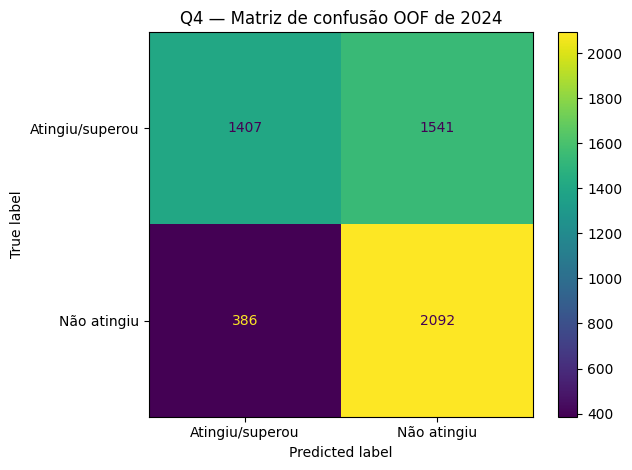

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_oof_q4_2024_threshold = (
    prob_oof_q4_2024 >= THRESHOLD_Q4
).astype(int)

tn_2024, fp_2024, fn_2024, tp_2024 = confusion_matrix(
    y_q4_2024,
    pred_oof_q4_2024_threshold,
    labels=[0, 1],
).ravel()

print('Matriz de confusão — probabilidades OOF de 2024')
print(f'TN: {tn_2024:,}')
print(f'FP: {fp_2024:,}')
print(f'FN: {fn_2024:,}')
print(f'TP: {tp_2024:,}')

matriz_confusao_oof_2024 = np.array([
    [tn_2024, fp_2024],
    [fn_2024, tp_2024],
])

disp_2024 = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_oof_2024,
    display_labels=[
        'Atingiu/superou',
        'Não atingiu',
    ],
)

disp_2024.plot()
plt.title('Q4 — Matriz de confusão OOF de 2024')
plt.tight_layout()
plt.show()

## 20. Congelamento da configuração de Q4

Antes de abrir o teste temporal, registramos explicitamente a configuração final de desenvolvimento:

| Elemento | Configuração |
|---|---|
| Modelo | Regressão Logística |
| `class_weight` | `'balanced'` |
| Tuning | não realizado |
| Threshold | `0,40` |
| Features | 37 features numéricas já definidas |
| Imputação | mediana, dentro do Pipeline |
| Scaling | `StandardScaler`, dentro do Pipeline |
| Métrica preditiva principal | PR-AUC |
| Métrica operacional prioritária | Recall |
| Desenvolvimento | 2024 |
| Teste temporal final | 2025 |

Nenhuma dessas decisões poderá ser modificada a partir do desempenho observado em 2025.

In [22]:
CONFIGURACAO_Q4 = {
    'modelo': 'Regressão Logística',
    'class_weight': 'balanced',
    'threshold': THRESHOLD_Q4,
    'n_features': len(FEATURES_Q4),
    'preprocessamento': 'SimpleImputer(median) + StandardScaler',
    'metrica_principal': 'PR-AUC',
    'metrica_operacional': 'Recall',
    'ano_desenvolvimento': 2024,
    'ano_teste_temporal': 2025,
}

display(
    pd.Series(CONFIGURACAO_Q4, name='configuracao')
    .to_frame()
)

,configuracao
modelo,Regressão Logística
class_weight,balanced
threshold,0.400
n_features,37
preprocessamento,SimpleImputer(median) + StandardScaler
metrica_principal,PR-AUC
metrica_operacional,Recall
ano_desenvolvimento,2024
ano_teste_temporal,2025


## 21. Checklist automático contra leakage

Antes de utilizar 2025, executamos uma auditoria programática.

O objetivo é confirmar que:

- o desenvolvimento usa somente 2024;
- identificadores e variáveis pós-desfecho não aparecem em `X`;
- `taxa_lag1` continua fora de `X`, evitando redundância com `meta` e `esforco_pactuado`;
- imputação e scaling permanecem dentro do `Pipeline`;
- o threshold foi definido exclusivamente com probabilidades OOF de 2024.

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Separação temporal do desenvolvimento.
assert set(dados_q4_2024['ano'].unique()) == {2024}

# Leakage e identificadores.
colunas_proibidas_q4 = [
    'taxa_realizada',
    'risco_nao_atingir_meta',
    'risco_educacional',
    'distancia_ate_a_meta',
    'proficiencia_media',
    'id_municipio',
    'id_uf',
    'nome_municipio',
    'ano',
]

for coluna in colunas_proibidas_q4:
    assert coluna not in X_q4_2024.columns, f'Leakage/identificador encontrado: {coluna}'

# Política do projeto e redundância.
assert 'pct_rede_municipal' not in X_q4_2024.columns
assert 'taxa_lag1' not in X_q4_2024.columns

# Configuração congelada.
assert THRESHOLD_Q4 == 0.40
assert modelo_q4_selecionado is modelo_logistica

# Preprocessing da Regressão Logística dentro do Pipeline.
# Como o objeto original ainda não foi ajustado em 100% de 2024,
# auditamos a definição do ColumnTransformer, e não atributos pós-fit.
preprocessador_auditado = modelo_q4_selecionado.named_steps['preprocessador']

transformadores_num = [
    transformador
    for nome, transformador, colunas in preprocessador_auditado.transformers
    if nome == 'num'
]

assert len(transformadores_num) == 1

pipeline_numerico_auditado = transformadores_num[0]

assert isinstance(
    pipeline_numerico_auditado.named_steps['imputer'],
    SimpleImputer
)
assert isinstance(
    pipeline_numerico_auditado.named_steps['scaler'],
    StandardScaler
)

print('Checklist contra leakage concluído.')
print('- desenvolvimento restrito a 2024')
print('- identificadores fora de X')
print('- variáveis pós-desfecho fora de X')
print('- pct_rede_municipal fora de X')
print('- taxa_lag1 fora de X')
print('- imputação dentro do Pipeline')
print('- scaling dentro do Pipeline')
print('- threshold congelado em 0,40')
print('- 2025 ainda não foi usado para desenvolvimento')

Checklist contra leakage concluído.
- desenvolvimento restrito a 2024
- identificadores fora de X
- variáveis pós-desfecho fora de X
- pct_rede_municipal fora de X
- taxa_lag1 fora de X
- imputação dentro do Pipeline
- scaling dentro do Pipeline
- threshold congelado em 0,40
- 2025 ainda não foi usado para desenvolvimento


## 22. Fit final em 100% de 2024

Com a configuração congelada, ajustamos uma nova cópia do pipeline usando todos os registros válidos de 2024.

Esse ajuste não é uma nova etapa de seleção. É apenas o treinamento final do modelo que será aplicado ao ano
seguinte.

In [24]:
from sklearn.base import clone

modelo_q4_final = clone(modelo_q4_selecionado)

modelo_q4_final.fit(
    X_q4_2024,
    y_q4_2024,
)

print('Modelo final ajustado em 100% dos dados válidos de 2024.')
print(f'Registros usados no fit: {len(X_q4_2024):,}')
print(f'Features utilizadas: {X_q4_2024.shape[1]}')

Modelo final ajustado em 100% dos dados válidos de 2024.
Registros usados no fit: 5,426
Features utilizadas: 37


## 23. Preparação do teste temporal — 2025

Somente agora abrimos o conjunto de 2025.

Aplicamos exatamente as mesmas regras definidas anteriormente:

- `meta == 0` permanece excluída;
- target precisa estar disponível para avaliação;
- usamos exatamente as mesmas `FEATURES_Q4`;
- não recalculamos medianas ou scaling manualmente;
- o Pipeline treinado em 2024 aplica suas transformações a 2025.

Os identificadores ficam separados e serão usados apenas nas análises posteriores de erros e ranking.

In [25]:
dados_q4_2025 = dados_q4.loc[
    dados_q4['ano'].eq(2025)
    & dados_q4[TARGET_Q4].notna()
].copy()

X_q4_2025 = dados_q4_2025[FEATURES_Q4].copy()

y_q4_2025 = pd.to_numeric(
    dados_q4_2025[TARGET_Q4],
    errors='raise',
).astype(int)

colunas_chave_2025 = [
    c for c in ['ano', 'id_uf', 'id_municipio', 'nome_municipio']
    if c in dados_q4_2025.columns
]

chaves_q4_2025 = dados_q4_2025[colunas_chave_2025].copy()

assert set(dados_q4_2025['ano'].unique()) == {2025}
assert X_q4_2025.columns.tolist() == X_q4_2024.columns.tolist()
assert X_q4_2025.index.equals(y_q4_2025.index)
assert not y_q4_2025.isna().any()
assert set(y_q4_2025.unique()).issubset({0, 1})

print('Shape de X_q4_2025:', X_q4_2025.shape)
print('Shape de y_q4_2025:', y_q4_2025.shape)

distribuicao_teste_q4 = (
    y_q4_2025
    .value_counts()
    .sort_index()
    .rename('municipios')
    .to_frame()
)

distribuicao_teste_q4['percentual'] = (
    distribuicao_teste_q4['municipios']
    / len(y_q4_2025)
    * 100
)

distribuicao_teste_q4.index = distribuicao_teste_q4.index.map({
    0: 'Atingiu/superou a meta',
    1: 'Não atingiu a meta',
})

display(distribuicao_teste_q4)

Shape de X_q4_2025: (5453, 37)
Shape de y_q4_2025: (5453,)


,municipios,percentual
risco_nao_atingir_meta,,
Atingiu/superou a meta,3953,72.492
Não atingiu a meta,1500,27.508


## 24. Teste temporal final — 2025

O modelo treinado em 2024 produz probabilidades para 2025.

A classe prevista será definida exclusivamente pelo threshold congelado:

```python
probabilidade >= 0.40
```

Calcularemos:

- PR-AUC;
- ROC-AUC;
- Recall;
- Precision;
- F1;
- Balanced Accuracy;
- Accuracy apenas como informação complementar;
- matriz de confusão;
- TN, FP, FN e TP.

Esses resultados medem **generalização temporal**. Depois de observá-los, não será permitido alterar modelo,
features, preprocessing, `class_weight` ou threshold.

In [26]:
from sklearn.metrics import accuracy_score

prob_q4_2025 = modelo_q4_final.predict_proba(
    X_q4_2025
)[:, 1]

pred_q4_2025 = (
    prob_q4_2025 >= THRESHOLD_Q4
).astype(int)

tn_2025, fp_2025, fn_2025, tp_2025 = confusion_matrix(
    y_q4_2025,
    pred_q4_2025,
    labels=[0, 1],
).ravel()

metricas_q4_2025 = pd.Series({
    'PR_AUC': average_precision_score(
        y_q4_2025,
        prob_q4_2025,
    ),
    'ROC_AUC': roc_auc_score(
        y_q4_2025,
        prob_q4_2025,
    ),
    'Recall': recall_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'Precision': precision_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'F1': f1_score(
        y_q4_2025,
        pred_q4_2025,
        zero_division=0,
    ),
    'Balanced_Accuracy': balanced_accuracy_score(
        y_q4_2025,
        pred_q4_2025,
    ),
    'Accuracy': accuracy_score(
        y_q4_2025,
        pred_q4_2025,
    ),
    'Threshold': THRESHOLD_Q4,
    'Municipios_sinalizados': int(pred_q4_2025.sum()),
    'Percentual_sinalizado': (
        pred_q4_2025.mean() * 100
    ),
    'TN': int(tn_2025),
    'FP': int(fp_2025),
    'FN': int(fn_2025),
    'TP': int(tp_2025),
})

print('Métricas — teste temporal final de 2025')
display(
    metricas_q4_2025
    .round(3)
    .rename('valor')
    .to_frame()
)

Métricas — teste temporal final de 2025


,valor
PR_AUC,0.555
ROC_AUC,0.737
Recall,0.805
Precision,0.375
F1,0.512
Balanced_Accuracy,0.648
Accuracy,0.578
Threshold,0.400
Municipios_sinalizados,"3,216.000"
Percentual_sinalizado,58.977


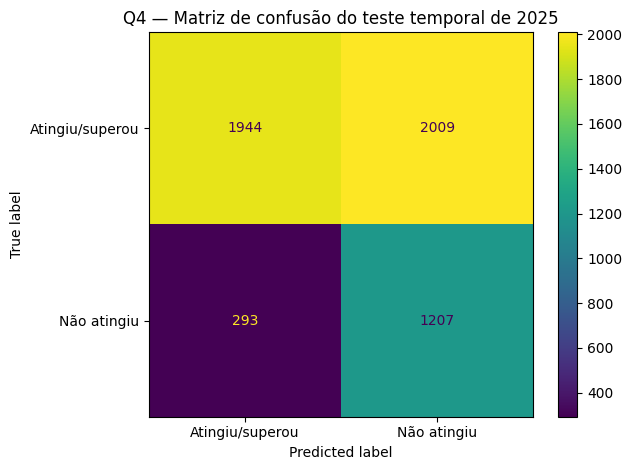

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

matriz_confusao_2025 = np.array([
    [tn_2025, fp_2025],
    [fn_2025, tp_2025],
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_2025,
    display_labels=[
        'Atingiu/superou',
        'Não atingiu',
    ],
)

disp.plot()
plt.title('Q4 — Matriz de confusão do teste temporal de 2025')
plt.tight_layout()
plt.show()

## 25. Comparação direta — validação OOF de 2024 × teste temporal de 2025

Para avaliar a **estabilidade temporal**, colocamos lado a lado:

- a matriz e as métricas obtidas com predições **OOF de 2024** no threshold congelado de `0,40`;
- a matriz e as métricas do **teste temporal de 2025**, produzido pelo modelo ajustado em 100% de 2024.

A avaliação OOF de 2024 é uma referência fora da amostra de cada fold, mas **não é um teste in-time independente**.
Já 2025 é o teste temporal final e simula de forma mais fiel a aplicação do modelo em um período futuro.

A comparação é exclusivamente diagnóstica. Nenhuma diferença observada em 2025 autoriza alterar modelo, features,
preprocessing, `class_weight` ou threshold.

Métricas comparativas — 2024 OOF × 2025 temporal


,Amostra,PR_AUC,ROC_AUC,Recall,Precision,F1,Balanced_Accuracy,Accuracy,Threshold,Delta_PR_AUC,Delta_ROC_AUC,Delta_Recall,Delta_Precision,Delta_F1,Delta_Balanced_Accuracy,Delta_Accuracy
0,Validação OOF 2024,0.673,0.738,0.844,0.576,0.685,0.661,0.645,0.400,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Teste temporal 2025,0.555,0.737,0.805,0.375,0.512,0.648,0.578,0.400,-0.118,-0.001,-0.040,-0.201,-0.173,-0.013,-0.067


Contagens das matrizes de confusão


,Amostra,TN,FP,FN,TP
0,Validação OOF 2024,1407,1541,386,2092
1,Teste temporal 2025,1944,2009,293,1207


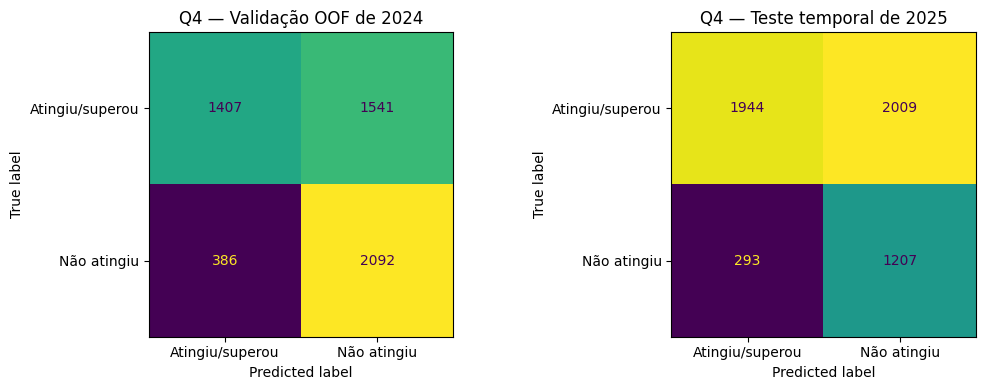

In [28]:
metricas_q4_oof_2024 = pd.Series({
    'PR_AUC': average_precision_score(
        y_q4_2024,
        prob_oof_q4_2024,
    ),
    'ROC_AUC': roc_auc_score(
        y_q4_2024,
        prob_oof_q4_2024,
    ),
    'Recall': recall_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),
    'Precision': precision_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),
    'F1': f1_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
        zero_division=0,
    ),
    'Balanced_Accuracy': balanced_accuracy_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
    ),
    'Accuracy': accuracy_score(
        y_q4_2024,
        pred_oof_q4_2024_threshold,
    ),
    'Threshold': THRESHOLD_Q4,
})

comparacao_temporal_q4 = pd.DataFrame([
    {
        'Amostra': 'Validação OOF 2024',
        **metricas_q4_oof_2024.to_dict(),
    },
    {
        'Amostra': 'Teste temporal 2025',
        **metricas_q4_2025[
            [
                'PR_AUC',
                'ROC_AUC',
                'Recall',
                'Precision',
                'F1',
                'Balanced_Accuracy',
                'Accuracy',
                'Threshold',
            ]
        ].to_dict(),
    },
])

metricas_delta_q4 = [
    'PR_AUC',
    'ROC_AUC',
    'Recall',
    'Precision',
    'F1',
    'Balanced_Accuracy',
    'Accuracy',
]

for metrica in metricas_delta_q4:
    comparacao_temporal_q4[f'Delta_{metrica}'] = (
        comparacao_temporal_q4[metrica]
        - comparacao_temporal_q4.loc[
            comparacao_temporal_q4['Amostra'].eq('Validação OOF 2024'),
            metrica,
        ].iloc[0]
    )

print('Métricas comparativas — 2024 OOF × 2025 temporal')
display(comparacao_temporal_q4.round(3))

comparacao_matrizes_q4 = pd.DataFrame([
    {
        'Amostra': 'Validação OOF 2024',
        'TN': int(tn_2024),
        'FP': int(fp_2024),
        'FN': int(fn_2024),
        'TP': int(tp_2024),
    },
    {
        'Amostra': 'Teste temporal 2025',
        'TN': int(tn_2025),
        'FP': int(fp_2025),
        'FN': int(fn_2025),
        'TP': int(tp_2025),
    },
])

print('Contagens das matrizes de confusão')
display(comparacao_matrizes_q4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_oof_2024,
    display_labels=['Atingiu/superou', 'Não atingiu'],
).plot(
    ax=axes[0],
    values_format='d',
    colorbar=False,
)
axes[0].set_title('Q4 — Validação OOF de 2024')
axes[0].grid(False)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_2025,
    display_labels=['Atingiu/superou', 'Não atingiu'],
).plot(
    ax=axes[1],
    values_format='d',
    colorbar=False,
)
axes[1].set_title('Q4 — Teste temporal de 2025')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 26. Conclusão da validação temporal

O teste temporal de 2025 permite avaliar se o modelo desenvolvido exclusivamente em 2024 manteve capacidade
de generalização no período seguinte.

A comparação foi:

| Métrica | OOF 2024 | Teste temporal 2025 |
|---|---:|---:|
| PR-AUC | 0,673 | 0,555 |
| ROC-AUC | 0,738 | 0,737 |
| Recall | 0,844 | 0,805 |
| Precision | 0,576 | 0,375 |
| F1 | 0,685 | 0,512 |
| Balanced Accuracy | 0,661 | 0,648 |

A prevalência da classe positiva caiu de aproximadamente **45,7% em 2024** para **27,5% em 2025**.
Mesmo com essa mudança, o ROC-AUC permaneceu praticamente estável e o Recall caiu apenas moderadamente.

A leitura conjunta das duas matrizes fornece uma evidência mais direta de **estabilidade temporal da classificação**.
Neste caso, não há uma ruptura generalizada das métricas: ROC-AUC, Recall e Balanced Accuracy permanecem próximos,
embora Precision e F1 se deteriorem com a mudança de prevalência e do perfil dos erros.

Essa comparação deve ser interpretada como um **diagnóstico de mudança temporal de desempenho**, e não como prova
isolada de *data drift* ou *concept drift*. Para caracterizar *data drift* seria necessário comparar as distribuições
das features entre 2024 e 2025; para *concept drift*, seria necessário investigar mudança na relação entre features e
target. Da mesma forma, sobreajuste é diagnosticado principalmente pela diferença entre treino e validação/OOF em
2024, análise já realizada anteriormente.


Com o threshold congelado em `0,40`, o modelo identificou corretamente:

- **1.207** dos 1.500 municípios que não atingiram a meta em 2025;
- Recall = **0,805**;
- falsos negativos = **293**.

Por outro lado, foram produzidos **2.009 falsos positivos**, o que reduziu a Precision para **0,375**.
Esse comportamento é coerente com a decisão operacional tomada em 2024 de priorizar Recall e aceitar mais
alertas em troca de reduzir o número de municípios de risco não sinalizados.

### Conclusão

A Regressão Logística apresentou **generalização temporal satisfatória para fins de triagem e priorização**.

O modelo não deve ser interpretado como uma classificação determinística. Sua utilidade principal é produzir
um **escore de risco** que ajude a identificar municípios que merecem atenção preventiva.

A partir deste ponto:

> **modelo, features, preprocessing, `class_weight` e threshold permanecem definitivamente congelados.**

Nenhum resultado de 2025 será usado para recalibrar a modelagem.

As etapas seguintes são exclusivamente de interpretação e aplicação:

> **análise de erros → ranking probabilístico → coeficientes da Regressão Logística → resposta final à Q4**

## 27. Análise de erros no teste temporal

As métricas globais não mostram quais municípios foram classificados corretamente ou incorretamente.

Vamos associar a cada município uma das quatro situações:

- verdadeiro negativo: atingiu a meta e não foi sinalizado;
- falso positivo: atingiu a meta, mas foi sinalizado;
- falso negativo: não atingiu a meta e não foi sinalizado;
- verdadeiro positivo: não atingiu a meta e foi sinalizado.

Nesta etapa, variáveis como `taxa_realizada` podem reaparecer **somente para auditoria do resultado de 2025**.
Elas não são utilizadas como preditores.

In [29]:
avaliacao_q4_2025 = chaves_q4_2025.copy()

# Variáveis de negócio usadas apenas para interpretar os resultados.
for coluna in [
    'meta',
    'taxa_lag1',
    'esforco_pactuado',
    'taxa_realizada',
]:
    if coluna in dados_q4_2025.columns:
        avaliacao_q4_2025[coluna] = dados_q4_2025[coluna]

avaliacao_q4_2025['probabilidade_nao_atingir_meta'] = prob_q4_2025
avaliacao_q4_2025['classe_prevista'] = pred_q4_2025
avaliacao_q4_2025['classe_real'] = y_q4_2025.to_numpy()

condicoes_resultado = [
    (
        avaliacao_q4_2025['classe_real'].eq(0)
        & avaliacao_q4_2025['classe_prevista'].eq(0)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(0)
        & avaliacao_q4_2025['classe_prevista'].eq(1)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(1)
        & avaliacao_q4_2025['classe_prevista'].eq(0)
    ),
    (
        avaliacao_q4_2025['classe_real'].eq(1)
        & avaliacao_q4_2025['classe_prevista'].eq(1)
    ),
]

rotulos_resultado = [
    'Verdadeiro negativo',
    'Falso positivo',
    'Falso negativo',
    'Verdadeiro positivo',
]

avaliacao_q4_2025['tipo_resultado'] = np.select(
    condicoes_resultado,
    rotulos_resultado,
    default='Revisar',
)

ordem_resultados = [
    'Verdadeiro negativo',
    'Falso positivo',
    'Falso negativo',
    'Verdadeiro positivo',
]

resumo_erros_q4 = (
    avaliacao_q4_2025['tipo_resultado']
    .value_counts()
    .reindex(ordem_resultados, fill_value=0)
    .rename('municipios')
    .to_frame()
)

resumo_erros_q4['percentual'] = (
    resumo_erros_q4['municipios']
    / len(avaliacao_q4_2025)
    * 100
)

display(resumo_erros_q4.round(3))

,municipios,percentual
tipo_resultado,,
Verdadeiro negativo,1944,35.650
Falso positivo,2009,36.842
Falso negativo,293,5.373
Verdadeiro positivo,1207,22.135


### 27.1 Falsos negativos

Os falsos negativos são especialmente importantes para Q4:

> municípios que efetivamente não atingiram a meta, mas não foram sinalizados pelo modelo.

Vamos mostrar os casos com maior probabilidade dentro desse grupo. Eles são erros que ficaram mais próximos
de serem sinalizados pelo threshold de `0,40`.

In [30]:
falsos_negativos_q4 = (
    avaliacao_q4_2025.loc[
        avaliacao_q4_2025['tipo_resultado'].eq('Falso negativo')
    ]
    .sort_values(
        'probabilidade_nao_atingir_meta',
        ascending=False,
    )
)

colunas_fn = [
    c for c in [
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'meta',
        'taxa_lag1',
        'esforco_pactuado',
        'taxa_realizada',
        'probabilidade_nao_atingir_meta',
    ]
    if c in falsos_negativos_q4.columns
]

print(f'Total de falsos negativos: {len(falsos_negativos_q4):,}')
display(
    falsos_negativos_q4[colunas_fn]
    .head(20)
    .reset_index(drop=True)
)

Total de falsos negativos: 293


,id_municipio,nome_municipio,id_uf,meta,taxa_lag1,esforco_pactuado,taxa_realizada,probabilidade_nao_atingir_meta
0,3507001,Boituva,35,68.000,69.830,-1.830,67.456,0.399
1,3514809,Eldorado,35,68.000,75.190,-7.190,58.621,0.398
2,3162575,São João do Manteninha,31,80.000,71.700,8.300,74.667,0.397
3,3540002,Pompéia,35,68.000,60.320,7.680,67.021,0.396
4,3525201,Jarinu,35,59.000,44.070,14.930,54.527,0.395
5,3144508,Nazareno,31,80.000,85.360,-5.360,75.490,0.395
6,3524709,Jaguariúna,35,68.000,70.220,-2.220,64.613,0.394
7,3148707,Pedra Azul,31,65.000,60.740,4.260,60.000,0.394
8,2103604,Coroatá,21,54.000,55.720,-1.720,46.233,0.394
9,3140159,Mário Campos,31,73.000,74.090,-1.090,72.826,0.393


### 27.2 Casos próximos ao threshold

Também é útil observar municípios cuja probabilidade ficou próxima de `0,40`.

Esses casos representam previsões de menor margem e ajudam a entender que o threshold é uma regra operacional,
não uma fronteira natural entre dois tipos de município.

In [31]:
avaliacao_q4_2025['distancia_ate_threshold'] = (
    avaliacao_q4_2025['probabilidade_nao_atingir_meta']
    - THRESHOLD_Q4
).abs()

casos_proximos_threshold_q4 = (
    avaliacao_q4_2025
    .sort_values('distancia_ate_threshold')
    .head(20)
)

colunas_proximos = [
    c for c in [
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'meta',
        'esforco_pactuado',
        'probabilidade_nao_atingir_meta',
        'classe_prevista',
        'classe_real',
        'tipo_resultado',
    ]
    if c in casos_proximos_threshold_q4.columns
]

display(
    casos_proximos_threshold_q4[colunas_proximos]
    .reset_index(drop=True)
)

,id_municipio,nome_municipio,id_uf,meta,esforco_pactuado,probabilidade_nao_atingir_meta,classe_prevista,classe_real,tipo_resultado
0,3163201,São José do Alegre,31,78.000,-8.260,0.400,0,0,Verdadeiro negativo
1,2919603,Macajuba,29,34.000,3.860,0.400,1,0,Falso positivo
2,3553807,Taquarituba,35,62.000,5.330,0.400,1,1,Verdadeiro positivo
3,1701002,Ananás,17,53.000,6.310,0.399,0,0,Verdadeiro negativo
4,2606606,Ibimirim,26,60.000,-1.760,0.399,0,0,Verdadeiro negativo
5,3205101,Viana,32,73.000,4.200,0.401,1,0,Falso positivo
6,3510708,Cardoso,35,72.000,12.140,0.401,1,0,Falso positivo
7,3507001,Boituva,35,68.000,-1.830,0.399,0,1,Falso negativo
8,3130606,Inconfidentes,31,80.000,-6.180,0.399,0,0,Verdadeiro negativo
9,5001003,Aparecida do Taboado,50,61.000,3.500,0.401,1,1,Verdadeiro positivo


## 28. Ranking probabilístico de risco

Para aplicação de negócio, a probabilidade prevista é mais informativa do que apenas a classe 0/1.

Ordenaremos os municípios de 2025 por:

```python
probabilidade_nao_atingir_meta
```

em ordem decrescente.

O target real de 2025 aparece apenas para auditoria do teste temporal.

> A probabilidade é um **escore de risco e priorização**, não uma certeza de descumprimento da meta.

In [32]:
ranking_q4_2025 = (
    avaliacao_q4_2025
    .sort_values(
        'probabilidade_nao_atingir_meta',
        ascending=False,
    )
    .reset_index(drop=True)
)

ranking_q4_2025.insert(
    0,
    'posicao_risco',
    np.arange(1, len(ranking_q4_2025) + 1),
)

colunas_ranking = [
    c for c in [
        'posicao_risco',
        'id_municipio',
        'nome_municipio',
        'id_uf',
        'meta',
        'taxa_lag1',
        'esforco_pactuado',
        'probabilidade_nao_atingir_meta',
        'classe_prevista',
        'classe_real',
        'tipo_resultado',
    ]
    if c in ranking_q4_2025.columns
]

print('Top 20 municípios por probabilidade estimada de não atingir a meta:')
display(
    ranking_q4_2025[colunas_ranking]
    .head(20)
)

Top 20 municípios por probabilidade estimada de não atingir a meta:


,posicao_risco,id_municipio,nome_municipio,id_uf,meta,taxa_lag1,esforco_pactuado,probabilidade_nao_atingir_meta,classe_prevista,classe_real,tipo_resultado
0,1,4301073,Arroio do Padre,43,80.000,18.200,61.800,0.981,1,1,Verdadeiro positivo
1,2,1303304,Novo Aripuanã,13,80.000,50.990,29.010,0.979,1,1,Verdadeiro positivo
2,3,2411106,Ruy Barbosa,24,65.000,35.000,30.000,0.978,1,0,Falso positivo
3,4,4320354,Sentinela do Sul,43,76.000,23.500,52.500,0.976,1,1,Verdadeiro positivo
4,5,1504307,Maracanã,15,72.000,47.510,24.490,0.976,1,1,Verdadeiro positivo
5,6,2411502,Santo Antônio,24,71.000,23.560,47.440,0.975,1,1,Verdadeiro positivo
6,7,4311122,Jaquirana,43,72.000,25.600,46.400,0.972,1,1,Verdadeiro positivo
7,8,1301654,Guajará,13,68.000,54.660,13.340,0.972,1,1,Verdadeiro positivo
8,9,4313953,Pantano Grande,43,75.000,25.700,49.300,0.972,1,1,Verdadeiro positivo
9,10,4304408,Canela,43,79.000,42.200,36.800,0.972,1,1,Verdadeiro positivo


## 29. Interpretação da Regressão Logística — coeficientes

Como todas as features da Regressão Logística foram padronizadas com `StandardScaler`, os coeficientes podem
ser comparados em uma escala comum.

A leitura será:

- coeficiente **positivo** → associado a aumento do escore de risco;
- coeficiente **negativo** → associado a redução do escore de risco;
- maior valor absoluto → maior peso na decisão linear do modelo.

Essa interpretação é **preditiva**, não causal.

Não devemos escrever que uma variável causa o não cumprimento da meta. O correto é dizer que ela está
associada a maior ou menor risco estimado pelo modelo.

In [33]:
preprocessador_final_q4 = modelo_q4_final.named_steps['preprocessador']
modelo_logistico_final_q4 = modelo_q4_final.named_steps['modelo']

nomes_features_transformadas = (
    preprocessador_final_q4
    .get_feature_names_out()
)

# O ColumnTransformer adiciona o prefixo "num__".
nomes_features_limpas = [
    nome.replace('num__', '', 1)
    for nome in nomes_features_transformadas
]

coeficientes_q4 = modelo_logistico_final_q4.coef_.ravel()

assert len(nomes_features_limpas) == len(coeficientes_q4)

tabela_coeficientes_q4 = pd.DataFrame({
    'feature': nomes_features_limpas,
    'coeficiente': coeficientes_q4,
})

tabela_coeficientes_q4['coeficiente_abs'] = (
    tabela_coeficientes_q4['coeficiente'].abs()
)

tabela_coeficientes_q4['direcao'] = np.where(
    tabela_coeficientes_q4['coeficiente'] > 0,
    'Aumenta o risco estimado',
    'Reduz o risco estimado',
)

tabela_coeficientes_q4 = (
    tabela_coeficientes_q4
    .sort_values(
        'coeficiente_abs',
        ascending=False,
    )
    .reset_index(drop=True)
)

print('Principais coeficientes em valor absoluto:')
display(
    tabela_coeficientes_q4
    .head(20)
    .round(4)
)

Principais coeficientes em valor absoluto:


,feature,coeficiente,coeficiente_abs,direcao
0,meta,1.406,1.406,Aumenta o risco estimado
1,ctx_inep_uf_media_portugues_lag1,-0.838,0.838,Reduz o risco estimado
2,proficiencia_lag1,-0.648,0.648,Reduz o risco estimado
3,ctx_atu_fundamental_anos_iniciais,0.436,0.436,Aumenta o risco estimado
4,ctx_atlas_taxa_analfabetismo_11a14,0.355,0.355,Aumenta o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.253,0.253,Reduz o risco estimado
6,participacao_lag1,-0.234,0.234,Reduz o risco estimado
7,ctx_atlas_taxa_analfabetismo_15a17,-0.194,0.194,Reduz o risco estimado
8,ctx_atlas_taxa_densidade_domiciliar,0.170,0.170,Aumenta o risco estimado
9,ctx_atu_fundamental_1_ano,-0.153,0.153,Reduz o risco estimado


In [34]:
print('Top 10 coeficientes positivos — associados a maior risco estimado:')
display(
    tabela_coeficientes_q4
    .sort_values('coeficiente', ascending=False)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

print('\nTop 10 coeficientes negativos — associados a menor risco estimado:')
display(
    tabela_coeficientes_q4
    .sort_values('coeficiente', ascending=True)
    .head(10)[
        ['feature', 'coeficiente', 'direcao']
    ]
    .round(4)
)

Top 10 coeficientes positivos — associados a maior risco estimado:


,feature,coeficiente,direcao
0,meta,1.406,Aumenta o risco estimado
3,ctx_atu_fundamental_anos_iniciais,0.436,Aumenta o risco estimado
4,ctx_atlas_taxa_analfabetismo_11a14,0.355,Aumenta o risco estimado
8,ctx_atlas_taxa_densidade_domiciliar,0.170,Aumenta o risco estimado
11,ctx_atlas_taxa_fora_escola_4a5,0.150,Aumenta o risco estimado
16,ctx_atlas_taxa_maes_chefes_familia,0.086,Aumenta o risco estimado
18,ctx_fundeb_nse_uf,0.078,Aumenta o risco estimado
19,ctx_atlas_taxa_frequencia_0a3,0.074,Aumenta o risco estimado
21,ctx_atlas_indice_gini,0.064,Aumenta o risco estimado
25,ctx_atu_creche,0.038,Aumenta o risco estimado



Top 10 coeficientes negativos — associados a menor risco estimado:


,feature,coeficiente,direcao
1,ctx_inep_uf_media_portugues_lag1,-0.838,Reduz o risco estimado
2,proficiencia_lag1,-0.648,Reduz o risco estimado
5,ctx_inep_uf_percentual_participacao_lag1,-0.253,Reduz o risco estimado
6,participacao_lag1,-0.234,Reduz o risco estimado
7,ctx_atlas_taxa_analfabetismo_15a17,-0.194,Reduz o risco estimado
9,ctx_atu_fundamental_1_ano,-0.153,Reduz o risco estimado
10,ctx_atlas_taxa_fora_escola_6a14,-0.153,Reduz o risco estimado
12,ctx_atu_fundamental_4_ano,-0.147,Reduz o risco estimado
13,ctx_atu_fundamental_5_ano,-0.138,Reduz o risco estimado
14,ctx_atlas_taxa_analfabetismo_15mais,-0.117,Reduz o risco estimado


# 30. Conclusão final — resposta à Q4

> **Q4 — Como prever municípios que podem não atingir metas futuras?**

## Foi possível prever?

**Sim.**

A Regressão Logística desenvolvida com dados de 2024 conseguiu identificar, no teste temporal de 2025,
municípios com maior probabilidade de não atingir a meta.

A configuração final foi definida exclusivamente em 2024:

- **modelo:** Regressão Logística;
- **features:** 37 variáveis numéricas disponíveis antes do resultado;
- **preprocessing:** imputação pela mediana e padronização;
- **class_weight:** `balanced`;
- **threshold operacional:** `0,40`;
- **métrica preditiva principal:** PR-AUC;
- **métrica operacional prioritária:** Recall.

Nenhuma decisão foi recalibrada após observar 2025.

## Desempenho temporal

A comparação entre desenvolvimento e teste temporal foi:

| Métrica | OOF 2024 | Teste temporal 2025 |
|---|---:|---:|
| PR-AUC | 0,673 | 0,555 |
| ROC-AUC | 0,738 | 0,737 |
| Recall | 0,844 | 0,805 |
| Precision | 0,576 | 0,375 |
| F1 | 0,685 | 0,512 |
| Balanced Accuracy | 0,661 | 0,648 |

O **ROC-AUC permaneceu praticamente estável**, mesmo com a mudança de prevalência do target entre os anos.
Isso indica que o modelo preservou sua capacidade de ordenar municípios de maior e menor risco.

Com threshold `0,40`, entre os **1.500 municípios que efetivamente não atingiram a meta em 2025**:

- **1.207 foram corretamente sinalizados**;
- **293 não foram identificados**;
- Recall = **80,5%**.

Portanto, o modelo conseguiu sinalizar antecipadamente cerca de **8 em cada 10 municípios** que não
atingiram a meta.

## Como interpretar o resultado operacionalmente?

A Precision em 2025 foi de **37,5%**, com **2.009 falsos positivos**.

Isso significa que o modelo não deve ser utilizado como uma afirmação do tipo:

> “este município certamente não atingirá a meta”.

A interpretação adequada é:

> **“este município apresenta um perfil que justifica maior atenção preventiva”.**

O modelo foi configurado deliberadamente para priorizar Recall. Assim, aceita mais falsos alertas em troca
de reduzir a quantidade de municípios de risco que passam sem sinalização.

Por isso, sua aplicação mais adequada é como ferramenta de **triagem, priorização e acompanhamento preventivo**.

## O ranking probabilístico acrescenta valor

A probabilidade prevista é mais útil do que apenas a classificação binária.

No **Top 20 municípios com maior probabilidade prevista de não atingir a meta**, **16 realmente não atingiram**
a meta em 2025.

Isso corresponde a **80% de verdadeiros positivos no Top 20**.

Esse resultado mostra que o ranking concentra bem os casos de maior risco e pode ser utilizado para apoiar
a priorização de municípios quando os recursos de acompanhamento são limitados.

A probabilidade deve ser interpretada como um **escore de risco**, e não como certeza de descumprimento.

## Quais informações mais contribuíram para a previsão?

Entre os maiores coeficientes em valor absoluto, destacaram-se:

### Associadas a maior risco estimado

- `meta`: **+1,406**;
- `ctx_atu_fundamental_anos_iniciais`: **+0,436**;
- `ctx_atlas_taxa_analfabetismo_11a14`: **+0,355**;
- `ctx_atlas_taxa_densidade_domiciliar`: **+0,170**;
- `ctx_atlas_taxa_fora_escola_4a5`: **+0,150**.

A variável `meta` apresentou o maior coeficiente positivo do modelo. Isso indica que, mantidas as demais
características constantes, metas mais altas estão associadas a maior risco estimado de não cumprimento.

### Associadas a menor risco estimado

- `ctx_inep_uf_media_portugues_lag1`: **-0,838**;
- `proficiencia_lag1`: **-0,648**;
- `ctx_inep_uf_percentual_participacao_lag1`: **-0,253**;
- `participacao_lag1`: **-0,234**.

Esses resultados mostram que o histórico educacional anterior, especialmente proficiência e participação,
possui informação relevante para a previsão temporal.

O `esforco_pactuado`, embora conceitualmente importante, não apareceu entre os maiores coeficientes absolutos.
Isso reforça que o risco não é bem explicado por uma regra simples isolada e é melhor estimado pela combinação
entre meta, histórico educacional e características estruturais do município.

## Síntese da resposta à Q4

> **Foi possível prever municípios que podem não atingir metas futuras com utilidade prática.**
>
> Utilizando informações conhecidas antes do resultado, uma Regressão Logística desenvolvida em 2024 e
> validada temporalmente em 2025 identificou **80,5% dos municípios que efetivamente não atingiram a meta**.
> A capacidade de discriminação permaneceu estável, com ROC-AUC de **0,737** em 2025. O modelo produz uma
> probabilidade que pode ser utilizada para ordenar e priorizar municípios para acompanhamento preventivo.
> Sua principal utilidade é como mecanismo de triagem e priorização, e não como previsão determinística.

# 31. Limitações e uso responsável

Os resultados devem ser interpretados considerando algumas limitações:

1. **Previsão não é causalidade.**  
   Os coeficientes representam associações condicionais utilizadas pelo modelo. Eles não demonstram que uma
   variável causa maior ou menor desempenho educacional.

2. **Há falsos positivos.**  
   A estratégia prioriza Recall e, por isso, muitos municípios sinalizados podem posteriormente atingir a meta.

3. **Há falsos negativos.**  
   Mesmo com Recall de 80,5%, 293 municípios que não atingiram a meta não foram sinalizados em 2025.

4. **O threshold é uma decisão operacional.**  
   Municípios com probabilidades próximas de `0,40` possuem perfis muito semelhantes, mesmo quando ficam em
   lados diferentes da classificação final.

5. **O modelo foi validado em 2025, não em 2026.**  
   Não é correto afirmar que o notebook já prevê 2026. O procedimento poderá ser aplicado a ciclos futuros
   quando estiverem disponíveis a meta do novo ciclo e as demais variáveis conhecidas antes do resultado.

6. **O ranking deve apoiar, e não substituir, a decisão pública.**  
   A probabilidade estimada pode ajudar a direcionar análises e ações preventivas, mas deve ser combinada com
   conhecimento territorial, capacidade operacional e outras evidências de política educacional.

## Encerramento

Com a validação temporal, análise de erros, ranking probabilístico e interpretação dos coeficientes, a Q4 está
respondida.

O produto final não é apenas uma classificação `risco / não risco`, mas um **escore ordenado de probabilidade**
que permite identificar quais municípios merecem maior atenção antes da observação do resultado educacional.